# Stage 5 — The Low-rank Neural Operator (LNO)

GNO makes the kernel integral tractable by *truncating* (locality) and *subsampling* (Nyström). LNO (Section 4.2 of the paper) takes a different route: restrict the kernel $\kappa(x,y)$ itself to be **low rank**:
$$\kappa(x,y) \approx \sum_{r=1}^{R} \phi_r(x)\,\psi_r(y)^\top$$
where $\phi_r : D \to \mathbb{R}^{d_{v_{out}}}$ and $\psi_r : D \to \mathbb{R}^{d_{v_{in}}}$ are learned basis functions (small coordinate-to-vector MLPs). Substituting into the integral operator and swapping the order of integration and summation:
$$(\mathcal{K}v)(x) = \int_D \kappa(x,y)v(y)\,dy = \sum_{r=1}^R \phi_r(x)\underbrace{\int_D \psi_r(y)\cdot v(y)\,dy}_{=:s_r}$$

The key trick: each $s_r$ is a **single scalar**, computed once via a sum over all $J$ grid points ($O(J)$), and then every output point $x$ only needs $O(R)$ work to combine the $R$ scalars $s_r$ via $\phi_r(x)$. Total cost: $O(RJ)$ instead of $O(J^2)$ — no truncation or subsampling needed, at the price of only being able to represent kernels well-approximated by $R$ "modes" (much like a truncated SVD). This is implemented in `neural_operators/models/lno.py`.

In [1]:
import sys, os, json
sys.path.append(os.path.abspath(".."))

import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

from neural_operators.models.lno import LNO2d
from neural_operators.utils import train_model, count_params, measure_inference_time, RelativeL2Loss

torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [2]:
cache = torch.load("../data_cache/navier_stokes_64.pt")
a_data, u_data = cache["a"], cache["u"]
n_train, n_test = cache["n_train"], cache["n_test"]

a_mean, a_std = a_data[:n_train].mean(), a_data[:n_train].std()
u_mean, u_std = u_data[:n_train].mean(), u_data[:n_train].std()
a_norm = (a_data - a_mean) / a_std
u_norm = (u_data - u_mean) / u_std

train_ds = TensorDataset(a_norm[:n_train], u_norm[:n_train])
test_ds = TensorDataset(a_norm[n_train:], u_norm[n_train:])
train_loader = DataLoader(train_ds, batch_size=20, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=20, shuffle=False)

In [3]:
model = LNO2d(in_channels=3, out_channels=1, width=32, n_layers=4, rank=16)
print("trainable parameters:", count_params(model))

history = train_model(model, train_loader, test_loader, epochs=150, lr=1e-3, device=device, verbose_every=10)

trainable parameters: 309761


epoch    0 | train rel-L2 0.9557 | test rel-L2 0.7542 | 0.8s


epoch   10 | train rel-L2 0.1057 | test rel-L2 0.1072 | 3.7s


epoch   20 | train rel-L2 0.0956 | test rel-L2 0.1024 | 6.4s


epoch   30 | train rel-L2 0.0862 | test rel-L2 0.0897 | 9.1s


...

epoch  110 | train rel-L2 0.0703 | test rel-L2 0.0729 | 30.5s


epoch  120 | train rel-L2 0.0698 | test rel-L2 0.0723 | 33.2s


epoch  130 | train rel-L2 0.0693 | test rel-L2 0.0718 | 35.9s


epoch  140 | train rel-L2 0.0692 | test rel-L2 0.0718 | 38.5s


epoch  149 | train rel-L2 0.0691 | test rel-L2 0.0717 | 40.9s


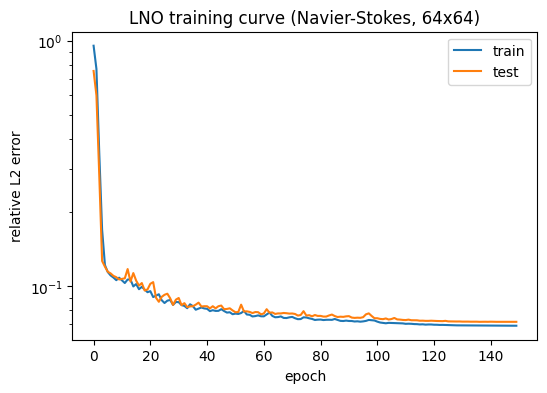

final test relative L2 error: 0.0717


In [4]:
plt.figure(figsize=(6, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch")
plt.ylabel("relative L2 error")
plt.yscale("log")
plt.legend()
plt.title("LNO training curve (Navier-Stokes, 64x64)")
plt.show()
print(f"final test relative L2 error: {history['test_loss'][-1]:.4f}")

## Qualitative check

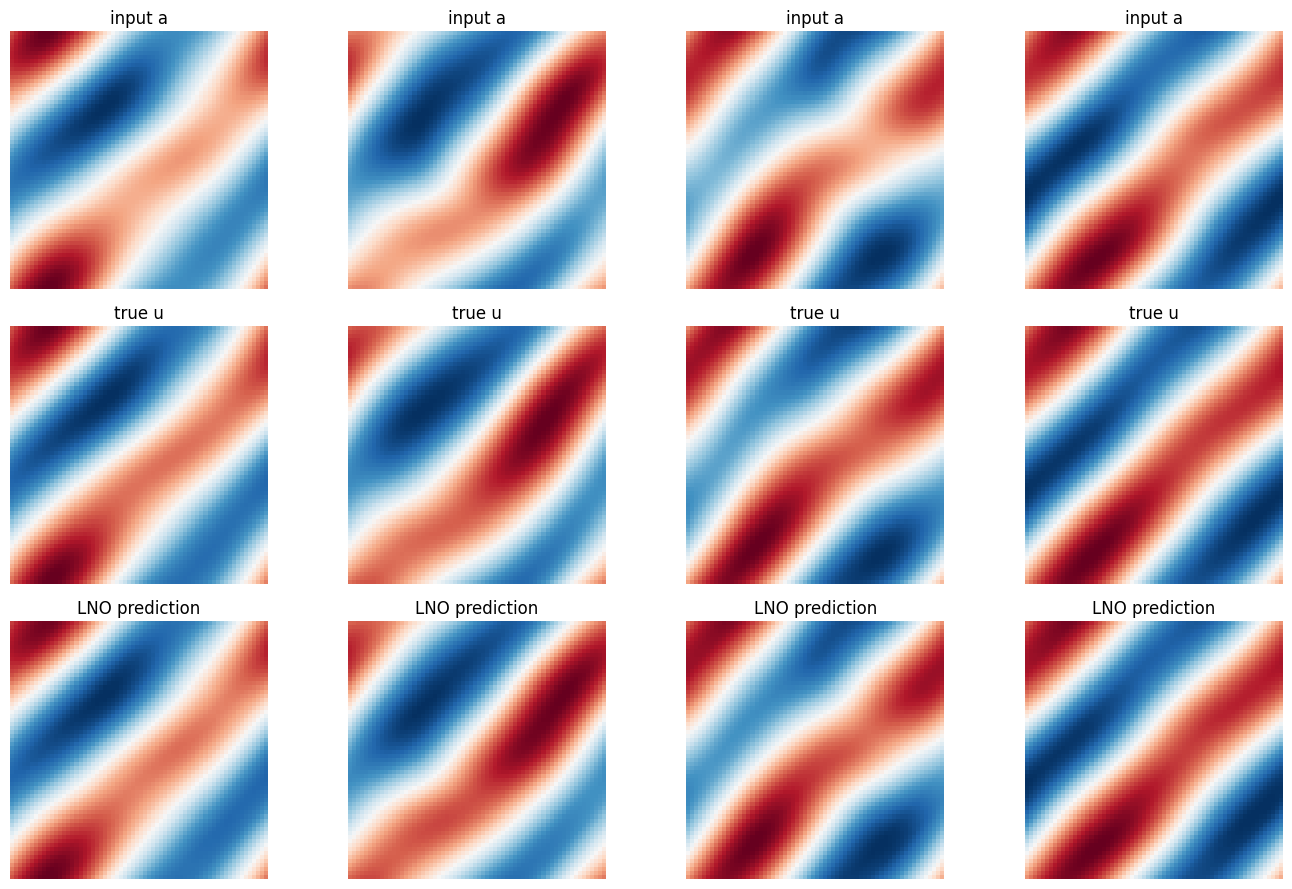

In [5]:
model.eval()
with torch.no_grad():
    x_sample, y_sample = next(iter(test_loader))
    pred = model(x_sample.to(device)).cpu()

fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for i in range(4):
    axes[0, i].imshow(x_sample[i] * a_std + a_mean, cmap="RdBu_r"); axes[0, i].set_title("input a"); axes[0, i].axis("off")
    axes[1, i].imshow(y_sample[i] * u_std + u_mean, cmap="RdBu_r"); axes[1, i].set_title("true u"); axes[1, i].axis("off")
    axes[2, i].imshow(pred[i] * u_std + u_mean, cmap="RdBu_r"); axes[2, i].set_title("LNO prediction"); axes[2, i].axis("off")
plt.tight_layout()
plt.show()

## Discretization invariance and rank sensitivity

First, the standard zero-shot resolution check. Then, since rank $R$ is LNO's key hyperparameter (a direct expressiveness/cost knob unique to this architecture), we also see how test error changes as $R$ varies, illustrating the low-rank approximation's expressiveness trade-off described in Section 4.2.

resolution   32x32   -> relative L2 error: 0.0812


resolution   64x64   -> relative L2 error: 0.0743


resolution   96x96   -> relative L2 error: 0.0737


resolution  128x128  -> relative L2 error: 0.0721


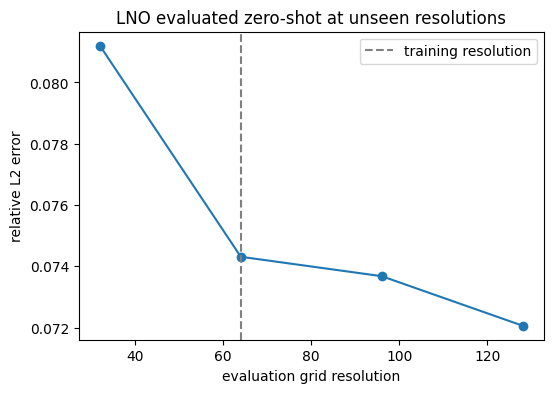

In [6]:
from neural_operators.data.grf import GaussianRF2d
from neural_operators.data.navier_stokes_2d import solve_navier_stokes_2d, default_forcing

def make_hr_test_set(n_hr, n_samples=20, seed=123):
    torch.manual_seed(seed)
    grf_hr = GaussianRF2d(n_hr, alpha=2.5, tau=7.0, device=device)
    f_hr = default_forcing(n_hr, device=device)
    w0 = grf_hr.sample(n_samples)
    burnin, _ = solve_navier_stokes_2d(w0, f_hr, visc=1e-3, T=4.5, delta_t=1e-3, record_steps=1)
    a = burnin[..., -1]
    traj, _ = solve_navier_stokes_2d(a, f_hr, visc=1e-3, T=2.0, delta_t=1e-3, record_steps=1)
    return a.cpu(), traj[..., -1].cpu()

resolutions = [32, 64, 96, 128]
errors = []
loss_fn = RelativeL2Loss()
for res in resolutions:
    a_res, u_res = make_hr_test_set(res, n_samples=20)
    a_res_n = (a_res - a_mean) / a_std
    u_res_n = (u_res - u_mean) / u_std
    with torch.no_grad():
        pred = model(a_res_n.to(device))
    err = loss_fn(pred.cpu(), u_res_n).item()
    errors.append(err)
    print(f"resolution {res:>4d}x{res:<4d} -> relative L2 error: {err:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(resolutions, errors, marker="o")
plt.axvline(64, color="gray", linestyle="--", label="training resolution")
plt.xlabel("evaluation grid resolution")
plt.ylabel("relative L2 error")
plt.title("LNO evaluated zero-shot at unseen resolutions")
plt.legend()
plt.show()

rank=  2 -> final test rel-L2 = 0.0813


rank=  4 -> final test rel-L2 = 0.0807


rank=  8 -> final test rel-L2 = 0.0804


rank= 16 -> final test rel-L2 = 0.0798


rank= 32 -> final test rel-L2 = 0.0796


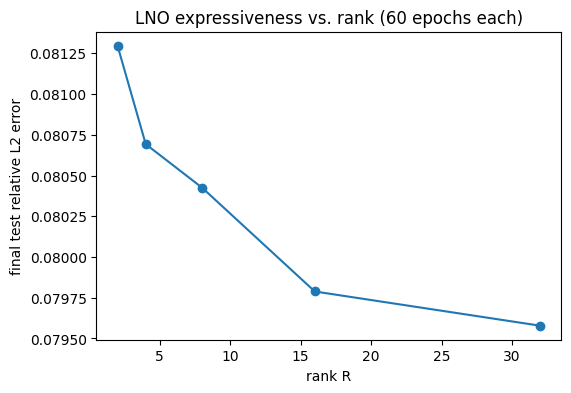

In [7]:
rank_sweep = [2, 4, 8, 16, 32]
rank_errors = []
for r in rank_sweep:
    m = LNO2d(in_channels=3, out_channels=1, width=32, n_layers=4, rank=r)
    h = train_model(m, train_loader, test_loader, epochs=60, lr=1e-3, device=device, verbose_every=0)
    rank_errors.append(h["test_loss"][-1])
    print(f"rank={r:3d} -> final test rel-L2 = {rank_errors[-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(rank_sweep, rank_errors, marker="o")
plt.xlabel("rank R")
plt.ylabel("final test relative L2 error")
plt.title("LNO expressiveness vs. rank (60 epochs each)")
plt.show()

We expect error to decrease as $R$ grows (more expressive kernel), with diminishing returns once $R$ is large enough to capture the dominant structure of the true kernel — directly illustrating the low-rank approximation trade-off from Section 4.2.

In [8]:
x_batch = a_norm[:20]
lno_time = measure_inference_time(model, x_batch, device=device)
print(f"LNO inference time per sample: {lno_time*1000:.3f} ms")

os.makedirs("../results", exist_ok=True)
torch.save(model.state_dict(), "../results/lno_navier_stokes.pt")
with open("../results/lno_summary.json", "w") as fp:
    json.dump({
        "params": count_params(model),
        "final_test_rel_l2": history["test_loss"][-1],
        "inference_time_s": lno_time,
        "discretization_invariance": dict(zip(resolutions, errors)),
        "rank_sweep": dict(zip(rank_sweep, rank_errors)),
    }, fp, indent=2)
print("saved model + summary to ../results/")

LNO inference time per sample: 9.981 ms
saved model + summary to ../results/


## Next step

`05_mgno.ipynb` implements the **Multipole Graph Neural Operator**, which combines GNO's local message passing with a coarse, multi-scale hierarchy (in the spirit of the fast multipole method) to capture long-range interactions cheaply, without either FNO's translation-invariance restriction or LNO's global low-rank restriction.